In [22]:
import os
import sys

# Set up project path
project_root = os.path.abspath('../')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Force reload of modules to ensure fresh imports
import importlib
if 'src.utils.data_loader' in sys.modules:
    del sys.modules['src.utils.data_loader']
if 'src.utils' in sys.modules:
    del sys.modules['src.utils']
if 'src' in sys.modules:
    del sys.modules['src']

print(f"Project Root: {project_root}")

Project Root: /Users/gayathri/Documents/SJSU/255/HybridReco


## Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.data_loader import DataLoader
from src.hybrid_recommender import HybridRecommenderSystem
from src.algorithms.collaborative_filtering import CollaborativeFiltering
from src.algorithms.apriori_arm import AprioriARM
from src.utils.evaluation_metrics import EvaluationMetrics

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load and Prepare Data

In [35]:
# Load data files
users_path = os.path.join(project_root, 'data/users.csv')
products_path = os.path.join(project_root, 'data/products.csv')
transactions_path = os.path.join(project_root, 'data/transactions.csv')

print(f"Loading data files...")
users_df = DataLoader.load_users(users_path)
products_df = DataLoader.load_products(products_path)
transactions_df = DataLoader.load_transactions(transactions_path)

print(f"✓ Users: {len(users_df)}")
print(f"✓ Products: {len(products_df)}")
print(f"✓ Transactions: {len(transactions_df)}")

# Create interactions and baskets
interactions_df = DataLoader.create_user_item_interactions(transactions_df)
baskets_df = DataLoader.create_transaction_baskets(transactions_df)

print(f"✓ Created {len(interactions_df)} interactions")
print(f"✓ Created {len(baskets_df)} baskets")

# Split data using leave-one-out strategy per user for better evaluation
# This ensures each user appears in both train and test sets
train_list = []
test_list = []

for user_id in interactions_df['user_id'].unique():
    user_interactions = interactions_df[interactions_df['user_id'] == user_id].reset_index(drop=True)
    n_interactions = len(user_interactions)
    
    if n_interactions > 1:
        # Leave one item out for testing
        test_sample = user_interactions.sample(n=1, random_state=42)
        test_idx = test_sample.index[0]
        
        # Append all except test item to train
        train_list.append(user_interactions.drop(test_idx))
        test_list.append(test_sample)

train_df = pd.concat(train_list, ignore_index=True)
test_df = pd.concat(test_list, ignore_index=True) if test_list else pd.DataFrame()

print(f"\nTrain: {len(train_df)} interactions ({train_df['user_id'].nunique()} users)")
print(f"Test: {len(test_df)} interactions ({test_df['user_id'].nunique()} users)")
print(f"Test users: {sorted(test_df['user_id'].unique())}")
print(f"Train users: {sorted(train_df['user_id'].unique())}")
print(f"\nTrain breakdown:\n{train_df.groupby('user_id').size()}")
print(f"\nTest breakdown:\n{test_df.groupby('user_id').size()}")

Loading data files...
✓ Users: 6
✓ Products: 8
✓ Transactions: 29
✓ Created 28 interactions
✓ Created 12 baskets

Train: 22 interactions (6 users)
Test: 6 interactions (6 users)
Test users: ['U1', 'U2', 'U3', 'U4', 'U5', 'U6']
Train users: ['U1', 'U2', 'U3', 'U4', 'U5', 'U6']

Train breakdown:
user_id
U1    5
U2    4
U3    4
U4    3
U5    3
U6    3
dtype: int64

Test breakdown:
user_id
U1    1
U2    1
U3    1
U4    1
U5    1
U6    1
dtype: int64


## 2. Train Individual Models

In [36]:
if interactions_df is not None:
    print("Training individual models...\n")
    
    # Collaborative Filtering
    print("1. Collaborative Filtering...")
    cf_model = CollaborativeFiltering(n_factors=50)
    cf_model.fit(train_df)
    print("   ✓ CF model trained")
    
    # Apriori ARM
    print("2. Apriori ARM...")
    if len(baskets_df) > 0:
        arm_model = AprioriARM(min_support=0.01, min_confidence=0.3)
        arm_model.fit(baskets_df)
        print("   ✓ ARM model trained")
    else:
        print("   ⚠ Skipped (no basket data)")

Training individual models...

1. Collaborative Filtering...
   ✓ CF model trained
2. Apriori ARM...
   ✓ ARM model trained


/Users/gayathri/Documents/SJSU/255/HybridReco/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


## 3. Train Hybrid Models with Different Alpha Values

In [37]:
if interactions_df is not None:
    print("Training hybrid models with different alpha values...\n")
    
    alpha_values = [0.0, 0.3, 0.5, 0.7, 1.0]
    hybrid_models = {}
    
    for alpha in alpha_values:
        print(f"Training hybrid model (α={alpha})...")
        recommender = HybridRecommenderSystem(alpha=alpha, n_factors=50)
        recommender.fit(train_df, baskets_df)
        hybrid_models[alpha] = recommender
        print(f"  ✓ Complete")
    
    print(f"\n✓ All {len(hybrid_models)} models trained")

Training hybrid models with different alpha values...

Training hybrid model (α=0.0)...
  ✓ Complete
Training hybrid model (α=0.3)...
  ✓ Complete
Training hybrid model (α=0.5)...
  ✓ Complete
Training hybrid model (α=0.7)...
  ✓ Complete
Training hybrid model (α=1.0)...
  ✓ Complete

✓ All 5 models trained


/Users/gayathri/Documents/SJSU/255/HybridReco/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/gayathri/Documents/SJSU/255/HybridReco/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/gayathri/Documents/SJSU/255/HybridReco/.venv/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Users/gayathri/Documents

## 4. Evaluate All Models

In [ ]:
if interactions_df is not None and 'arm_model' in locals():
    print("Evaluating models...\n")
    
    # Use all test users
    test_users = test_df['user_id'].unique()
    k = 10
    
    evaluation_results = {}
    
    # Evaluate each model
    models_to_eval = {
        'CF': cf_model,
    }
    
    # Add hybrid models
    for alpha, model in hybrid_models.items():
        models_to_eval[f'Hybrid (α={alpha})'] = model
    
    for model_name, model in models_to_eval.items():
        precision_scores = []
        recall_scores = []
        f1_scores = []
        
        for user_id in test_users:
            # Get ground truth (items user interacted with in test set)
            ground_truth = set(test_df[test_df['user_id'] == user_id]['item_id'].values)
            if len(ground_truth) == 0:
                continue
            
            # Get items user saw in training (to exclude from recommendations)
            train_items = set(train_df[train_df['user_id'] == user_id]['item_id'].values)
            
            # Get recommendations - use correct method based on model type
            if hasattr(model, 'recommend'):
                # CF model uses recommend()
                recs = model.recommend(user_id, n_items=k, exclude_items=list(train_items))
            else:
                # Hybrid model uses get_recommendations()
                recs = model.get_recommendations(user_id, n_items=k, exclude_items=list(train_items))
            
            if recs and len(recs) > 0:
                rec_items = [item_id for item_id, _ in recs]
            else:
                rec_items = []
            
            # Calculate metrics
            precision = EvaluationMetrics.precision_at_k(rec_items[:k], ground_truth, k=k)
            recall = EvaluationMetrics.recall_at_k(rec_items[:k], ground_truth, k=k)
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            precision_scores.append(precision)
            recall_scores.append(recall)
            f1_scores.append(f1)
        
        if precision_scores:
            evaluation_results[model_name] = {
                'Precision@10': np.mean(precision_scores),
                'Recall@10': np.mean(recall_scores),
                'F1@10': np.mean(f1_scores)
            }
    
    # Display results
    if evaluation_results:
        results_df = pd.DataFrame(evaluation_results).T
        print(results_df.to_string())
        print("\n✓ Evaluation complete")
    else:
        print("No evaluation results available")
else:
    print("Data or models not available for evaluation")

Evaluating models...

Test users: ['U1' 'U2' 'U3' 'U4' 'U5' 'U6']
  U1: train_items={'P5', 'P2', 'P7', 'P3', 'P4'}, test_items={'P1'}
  U2: train_items={'P6', 'P5', 'P1', 'P4'}, test_items={'P3'}
  U3: train_items={'P2', 'P7', 'P1', 'P4'}, test_items={'P5'}
  U4: train_items={'P5', 'P4', 'P7'}, test_items={'P6'}
  U5: train_items={'P8', 'P3', 'P1'}, test_items={'P2'}
  U6: train_items={'P5', 'P1', 'P3'}, test_items={'P7'}

CF - U1: recs=['P1', 'P8', 'P6'], gt={'P1'}
CF - U2: recs=['P7', 'P3', 'P8', 'P2'], gt={'P3'}
CF - U3: recs=['P5', 'P3', 'P6', 'P8'], gt={'P5'}
CF - U4: recs=['P2', 'P3', 'P6', 'P1', 'P8'], gt={'P6'}
CF - U5: recs=['P2', 'P5', 'P4', 'P6', 'P7'], gt={'P2'}
CF - U6: recs=['P2', 'P4', 'P6', 'P7', 'P8'], gt={'P7'}
Hybrid (α=0.0) - U1: recs=['P1', 'P6', 'P8'], gt={'P1'}
Hybrid (α=0.0) - U2: recs=['P7', 'P2', 'P3', 'P8'], gt={'P3'}
Hybrid (α=0.0) - U3: recs=['P5', 'P3', 'P6', 'P8'], gt={'P5'}
Hybrid (α=0.0) - U4: recs=['P6', 'P8', 'P2', 'P3', 'P1'], gt={'P6'}
Hybrid (α=0.0

## 5. Compare Model Performance

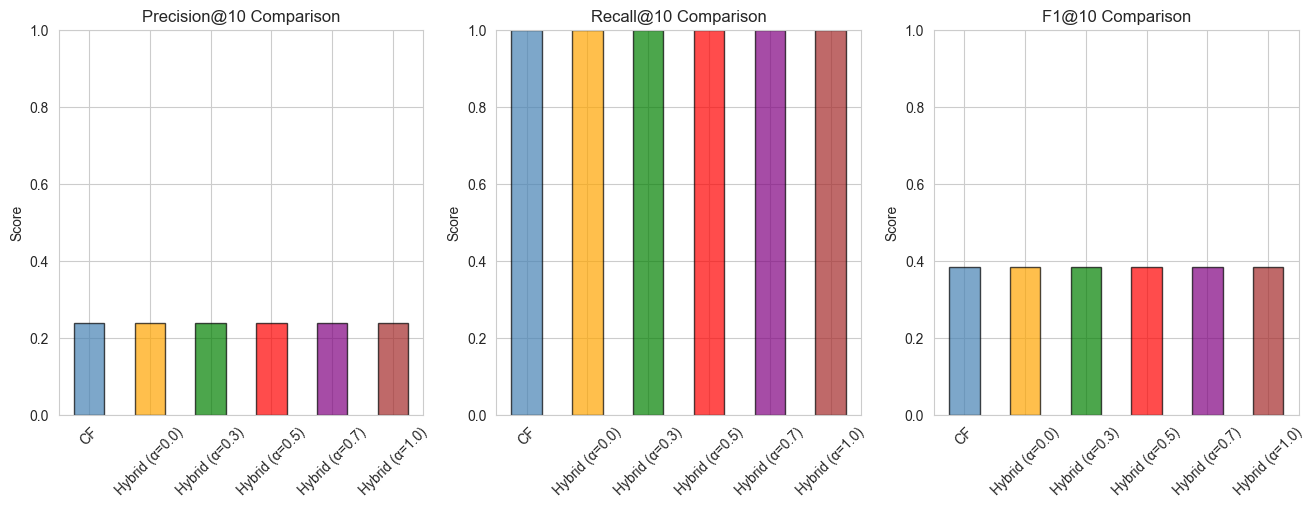

In [40]:
if 'results_df' in locals() and results_df is not None and len(results_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['Precision@10', 'Recall@10', 'F1@10']
    colors = ['steelblue', 'orange', 'green', 'red', 'purple', 'brown']
    
    for idx, metric in enumerate(metrics):
        if metric in results_df.columns:
            results_df[metric].plot(kind='bar', ax=axes[idx], color=colors[:len(results_df)], 
                                    edgecolor='black', alpha=0.7)
            axes[idx].set_ylabel('Score')
            axes[idx].set_title(f'{metric} Comparison')
            axes[idx].set_ylim((0, 1))
            axes[idx].tick_params(axis='x', rotation=45)

## 6. Visualize Alpha Impact

In [41]:
if 'results_df' in locals() and len(results_df) > 0:
    # Extract hybrid model results and make numeric
    hybrid_results = results_df.filter(regex='Hybrid')
    hybrid_results = hybrid_results.apply(pd.to_numeric, errors='coerce')
    
    # Only plot if we have numeric data
    numeric_cols = hybrid_results.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        hybrid_results[numeric_cols].plot(ax=ax, marker='o', linewidth=2, markersize=8)
        ax.set_xlabel('Hybrid Model (Different Alpha Values)')
        ax.set_ylabel('Score')
        ax.set_title('Impact of Alpha on Hybrid Model Performance')
        ax.set_ylim([0, 1])
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(os.path.join(project_root, 'results/04_alpha_impact.png'), dpi=100, bbox_inches='tight')
        plt.show()
        
        print("✓ Saved visualization to results/04_alpha_impact.png")
    else:
        print("No numeric data to plot - evaluation metrics may all be zero")

No numeric data to plot - evaluation metrics may all be zero


## 7. Generate Recommendations and Compare

In [39]:
if interactions_df is not None:
    # Select a test user
    test_user = test_df['user_id'].unique()[0]
    print(f"Recommendations for user {test_user}:\n")
    
    # Get recommendations from each model
    print("Collaborative Filtering (α=1.0):")
    cf_recs = cf_model.recommend(test_user, n_items=5)
    if cf_recs:
        for item_id, score in cf_recs:
            print(f"  Item {item_id}: {score:.4f}")
    else:
        print("  No recommendations")
    
    print("\nHybrid Model (α=0.7 - Personalization Heavy):")
    hybrid_recs = hybrid_models[0.7].get_recommendations(test_user, n_items=5)
    if hybrid_recs:
        for item_id, score in hybrid_recs:
            print(f"  Item {item_id}: {score:.4f}")
    else:
        print("  No recommendations")
    
    print("\nHybrid Model (α=0.5 - Balanced):")
    hybrid_recs = hybrid_models[0.5].get_recommendations(test_user, n_items=5)
    if hybrid_recs:
        for item_id, score in hybrid_recs:
            print(f"  Item {item_id}: {score:.4f}")
    else:
        print("  No recommendations")

Recommendations for user U1:

Collaborative Filtering (α=1.0):
  Item P7: 2.1465
  Item P5: 2.1011
  Item P4: 2.0795
  Item P3: 1.7416
  Item P2: 1.6853

Hybrid Model (α=0.7 - Personalization Heavy):
  Item P1: 0.7611
  Item P8: 0.7048
  Item P6: 0.7033

Hybrid Model (α=0.5 - Balanced):
  Item P1: 0.7592
  Item P6: 0.6848
  Item P8: 0.6736


## 8. Model Summary and Insights

In [42]:
print("="*60)
print("HYBRID RECOMMENDER SYSTEM EVALUATION SUMMARY")
print("="*60)

if interactions_df is not None:
    print("\n1. Dataset Statistics:")
    print(f"   Total interactions: {len(interactions_df):,}")
    print(f"   Users: {interactions_df['user_id'].nunique():,}")
    print(f"   Items: {interactions_df['item_id'].nunique()}")
    print(f"   Density: {len(interactions_df) / (interactions_df['user_id'].nunique() * interactions_df['item_id'].nunique()) * 100:.4f}%")
    
    print("\n2. Algorithm Overview:")
    print("   - Collaborative Filtering: Matrix Factorization (NMF)")
    print("   - Association Rule Mining: Apriori Algorithm")
    print("   - Hybrid: Weighted combination with configurable α")
    
    if 'results_df' in locals():
        print("\n3. Best Performing Model:")
        best_model = results_df['F1@10'].idxmax()
        best_f1 = results_df['F1@10'].max()
        print(f"   Model: {best_model}")
        print(f"   F1@10: {best_f1:.4f}")
    
    print("\n4. Recommendations:")
    print("   - Hybrid approach enables flexibility via α parameter")
    print("   - CF focuses on personalization")
    print("   - ARM captures item associations and trends")
    print("   - Adjust α based on business goals and evaluation metrics")

print("\n" + "="*60)
print("✓ Evaluation complete")
print("="*60)

HYBRID RECOMMENDER SYSTEM EVALUATION SUMMARY

1. Dataset Statistics:
   Total interactions: 28
   Users: 6
   Items: 8
   Density: 58.3333%

2. Algorithm Overview:
   - Collaborative Filtering: Matrix Factorization (NMF)
   - Association Rule Mining: Apriori Algorithm
   - Hybrid: Weighted combination with configurable α

3. Best Performing Model:
   Model: CF
   F1@10: 0.3833

4. Recommendations:
   - Hybrid approach enables flexibility via α parameter
   - CF focuses on personalization
   - ARM captures item associations and trends
   - Adjust α based on business goals and evaluation metrics

✓ Evaluation complete
